# Тестирование обученных моделей

In [1]:
import os 
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torchaudio
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.utils.data import Dataset, DataLoader
from torch.nn.parameter import Parameter

from scipy.optimize import brentq
from scipy.interpolate import interp1d
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from tqdm.auto import tqdm

import warnings
warnings.filterwarnings("ignore")


DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Device set to use: {DEVICE}")

Device set to use: cuda


In [2]:
DATASET_PATH = "../russian_sdd_dataset"

train_df = pd.read_csv(os.path.join(DATASET_PATH, 'train.csv'), index_col=0)
train_paths = [os.path.join(DATASET_PATH, audio) for audio in train_df['audio']]

test_df = pd.read_csv(os.path.join(DATASET_PATH, 'test.csv'), index_col=0)
test_paths = [os.path.join(DATASET_PATH, audio) for audio in test_df['audio']]

In [3]:
def load_audio(audio_path: str) -> torch.Tensor:
    sample_rate = 16_000
    
    wav, sr = torchaudio.load(audio_path)
        
    if sr != sample_rate:
        wav = torchaudio.transforms.Resample(sr, sample_rate)(wav)
            
    if wav.shape[0] > 1:
        wav = wav.mean(dim=0, keepdim=True)
            
    return wav

In [4]:
train_audios = [load_audio(audio) for audio in tqdm(train_paths)]
test_audios = [load_audio(audio) for audio in tqdm(test_paths)]

  0%|          | 0/13200 [00:00<?, ?it/s]

  0%|          | 0/3360 [00:00<?, ?it/s]

In [5]:
class TestRSDDDataset(Dataset):
    def __init__(self, audios, target_len):
        self.audios = audios
        self.target_len = target_len 

    def __len__(self):
        return len(self.audios)

    def _preprocess_audio(self, audio):
        if audio.shape[-1] >= self.target_len:
            return audio[:, :self.target_len]
        else:
            n_repeat = self.target_len // audio.shape[-1] + 1
            return audio.repeat(1, n_repeat)[:, :self.target_len]

    def __getitem__(self, idx):
        audio = self.audios[idx]
        return self._preprocess_audio(audio)

In [6]:
def get_probas(model, dataloader):
    model.eval()
    probas = []
    with torch.no_grad():
        for batch in tqdm(dataloader):
            batch = batch.to(DEVICE)
            outputs = model(batch).squeeze()
            probas.extend(torch.sigmoid(outputs).cpu().numpy())
    return probas

In [7]:
target_len = int(5.0 * 16_000)

train_dataset = TestRSDDDataset(train_audios, target_len)
test_dataset = TestRSDDDataset(test_audios, target_len)

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False)

### Функции расчёта метрик и визуализаций

In [8]:
def calculate_eer(y_true, y_probas):
    """Рассчитывает EER и соответствующий порог"""
    fpr, tpr, thresholds = roc_curve(y_true, y_probas, pos_label=1)
    
    eer = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
    thresh = interp1d(fpr, thresholds)(eer)
    
    return fpr, tpr, thresholds, eer, thresh


def visualize_eer(y_true, models_dict, title="Сравнение ROC-кривых"):
    """
    Строит ROC-кривые для всех моделей на одном графике
    """
    
    plt.figure(figsize=(12, 10))
    
    colors = plt.cm.Set2(np.linspace(0, 1, len(models_dict)))
    
    line_styles = ['-', '--', '-.', ':']
    
    results = dict()
    
    for i, (model_name, y_probas) in enumerate(models_dict.items()):
        fpr, tpr, thresholds, eer, thresh = calculate_eer(y_true, y_probas)

        results[model_name] = {
            'EER': eer,
            'Threshold': thresh
        }
        
        line_style = line_styles[i % len(line_styles)]
        plt.plot(fpr, tpr, 
                color=colors[i],
                linestyle=line_style,
                linewidth=2.5,
                label=f'{model_name} (EER = {eer:.3f})')
        
        plt.scatter(eer, 1 - eer, 
                   color=colors[i], 
                   s=100, 
                   edgecolors='black',
                   linewidth=1.5,
                   zorder=5)
    
    # Диагональная линия (случайный классификатор)
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.6, linewidth=1.5, label='Cлучайный классификатор', color='red')
    # Диагональная линия (случайный классификатор)
    plt.plot([1, 0], [0, 1], 'k--', alpha=0.6, linewidth=1.5)
    
    # Настройки графика
    plt.xlim([-0.01, 1.01])
    plt.ylim([-0.01, 1.01])
    plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold')
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    
    # Легенда
    plt.legend(loc='lower right', fontsize=11, framealpha=0.95, edgecolor='black')
    
    # Сетка
    plt.grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    return results

## 1. RawNetLite

In [10]:
class ResBlock(nn.Module):
    def __init__(self, channels):
        super(ResBlock, self).__init__()
        self.conv1 = nn.Conv1d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(channels)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv1d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(channels)

    def forward(self, x):
        residual = x
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        return self.relu(x + residual)



class RawNetLite(nn.Module):
    def __init__(self):
        super(RawNetLite, self).__init__()
        self.conv_pre = nn.Conv1d(1, 64, kernel_size=3, stride=1, padding=1)
        self.bn_pre = nn.BatchNorm1d(64)
        self.relu = nn.ReLU()

        self.resblock1 = ResBlock(64)
        self.resblock2 = ResBlock(64)
        self.resblock3 = ResBlock(64)

        self.pool = nn.AdaptiveAvgPool1d(64)

        self.gru = nn.GRU(input_size=64, hidden_size=128, num_layers=1,
                          batch_first=True, bidirectional=True)

        self.fc1 = nn.Linear(128 * 2, 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.relu(self.bn_pre(self.conv_pre(x)))     
        x = self.resblock1(x)
        x = self.resblock2(x)
        x = self.resblock3(x)
        x = self.pool(x)                                

        x = x.transpose(1, 2)                           
        output, _ = self.gru(x)                       
        x = output[:, -1, :]                           

        x = self.fc1(x)                   
        x = self.fc2(x)          
        return x

In [11]:
rawnetlite = RawNetLite().to(DEVICE)

rawnetlite_weights = torch.load('./rawnetlite_trained.pt')['model_state_dict']

rawnetlite.load_state_dict(rawnetlite_weights)

<All keys matched successfully>

In [12]:
rawnetlite_train_probas = get_probas(rawnetlite, train_dataloader)
rawnetlite_test_probas = get_probas(rawnetlite, test_dataloader)

  0%|          | 0/207 [00:00<?, ?it/s]

  0%|          | 0/53 [00:00<?, ?it/s]

In [13]:
_, _, _, rawnetlite_train_eer, rawnetlite_train_thr = calculate_eer(train_df['label'], rawnetlite_train_probas)
_, _, _, rawnetlite_test_eer, _ = calculate_eer(test_df['label'], rawnetlite_test_probas)
rawnetlite_test_predictions = [int(prob >= rawnetlite_train_thr) for prob in rawnetlite_test_probas]
rawnetlite_test_accuracy = accuracy_score(test_df['label'], rawnetlite_test_predictions)

print(f"{'='*25} RawNetLite {'='*25}")
print(f"Train EER: {round(rawnetlite_train_eer, 3)}  |  Train threshold: {round(rawnetlite_train_thr.item(), 3)}")
print(f"Test EER: {round(rawnetlite_test_eer, 3)}  |  Test accuracy: {round(rawnetlite_test_accuracy, 3)} (train threshold)")

========================= RawNetLite =========================
Train EER: 0.103  |  Train threshold: 0.492
Test EER: 0.111  |  Test accuracy: 0.888 (train threshold)


## 2. RawNet2 

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
import numpy as np
import math
from torch.utils import data
from collections import OrderedDict
from torch.nn.parameter import Parameter
from torch.autograd import Variable
import pickle
import random


class SincConv(nn.Module):
    @staticmethod
    def to_mel(hz):
        return 2595 * np.log10(1 + hz / 700)

    @staticmethod
    def to_hz(mel):
        return 700 * (10 ** (mel / 2595) - 1)


    def __init__(self, device,out_channels, kernel_size,in_channels=1,sample_rate=16000,
                 stride=1, padding=0, dilation=1, bias=False, groups=1,freq_scale='Mel'):

        super(SincConv,self).__init__()


        if in_channels != 1:
            
            msg = "SincConv only support one input channel (here, in_channels = {%i})" % (in_channels)
            raise ValueError(msg)
        
        self.out_channels = out_channels+1
        self.kernel_size = kernel_size
        self.sample_rate=sample_rate

        # Forcing the filters to be odd (i.e, perfectly symmetrics)
        if kernel_size%2==0:
            self.kernel_size=self.kernel_size+1

        self.device=device   
        self.stride = stride
        self.padding = padding
        self.dilation = dilation
        
        if bias:
            raise ValueError('SincConv does not support bias.')
        if groups > 1:
            raise ValueError('SincConv does not support groups.')
        
        
        # initialize filterbanks using Mel scale
        NFFT = 512
        f=int(self.sample_rate/2)*np.linspace(0,1,int(NFFT/2)+1)


        if freq_scale == 'Mel':
            fmel=self.to_mel(f) # Hz to mel conversion
            fmelmax=np.max(fmel)
            fmelmin=np.min(fmel)
            filbandwidthsmel=np.linspace(fmelmin,fmelmax,self.out_channels+2)
            filbandwidthsf=self.to_hz(filbandwidthsmel) # Mel to Hz conversion
            self.freq=filbandwidthsf[:self.out_channels]

        elif freq_scale == 'Inverse-mel':
            fmel=self.to_mel(f) # Hz to mel conversion
            fmelmax=np.max(fmel)
            fmelmin=np.min(fmel)
            filbandwidthsmel=np.linspace(fmelmin,fmelmax,self.out_channels+2)
            filbandwidthsf=self.to_hz(filbandwidthsmel) # Mel to Hz conversion
            self.mel=filbandwidthsf[:self.out_channels]
            self.freq=np.abs(np.flip(self.mel)-1) ## invert mel scale

        
        else:
            fmelmax=np.max(f)
            fmelmin=np.min(f)
            filbandwidthsmel=np.linspace(fmelmin,fmelmax,self.out_channels+2)
            self.freq=filbandwidthsmel[:self.out_channels]
        
        self.hsupp=torch.arange(-(self.kernel_size-1)/2, (self.kernel_size-1)/2+1)
        self.band_pass=torch.zeros(self.out_channels-1,self.kernel_size)
       
        
    def forward(self,x):
        for i in range(len(self.freq)-1):
            fmin=self.freq[i]
            fmax=self.freq[i+1]
            hHigh=(2*fmax/self.sample_rate)*np.sinc(2*fmax*self.hsupp/self.sample_rate)
            hLow=(2*fmin/self.sample_rate)*np.sinc(2*fmin*self.hsupp/self.sample_rate)
            hideal=hHigh-hLow
            
            self.band_pass[i,:]=Tensor(np.hamming(self.kernel_size))*Tensor(hideal)
        
        band_pass_filter=self.band_pass.to(self.device)

        self.filters = (band_pass_filter).view(self.out_channels-1, 1, self.kernel_size)
        
        return F.conv1d(x, self.filters, stride=self.stride,
                        padding=self.padding, dilation=self.dilation,
                         bias=None, groups=1)


        
class Residual_block(nn.Module):
    def __init__(self, nb_filts, first = False):
        super(Residual_block, self).__init__()
        self.first = first
        
        if not self.first:
            self.bn1 = nn.BatchNorm1d(num_features = nb_filts[0])
        
        self.lrelu = nn.LeakyReLU(negative_slope=0.3)
        
        self.conv1 = nn.Conv1d(in_channels = nb_filts[0],
			out_channels = nb_filts[1],
			kernel_size = 3,
			padding = 1,
			stride = 1)
        
        self.bn2 = nn.BatchNorm1d(num_features = nb_filts[1])
        self.conv2 = nn.Conv1d(in_channels = nb_filts[1],
			out_channels = nb_filts[1],
			padding = 1,
			kernel_size = 3,
			stride = 1)
        
        if nb_filts[0] != nb_filts[1]:
            self.downsample = True
            self.conv_downsample = nn.Conv1d(in_channels = nb_filts[0],
				out_channels = nb_filts[1],
				padding = 0,
				kernel_size = 1,
				stride = 1)
            
        else:
            self.downsample = False
        self.mp = nn.MaxPool1d(3)
        
    def forward(self, x):
        identity = x
        if not self.first:
            out = self.bn1(x)
            out = self.lrelu(out)
        else:
            out = x
            
        out = self.conv1(out)
        out = self.bn2(out)
        out = self.lrelu(out)
        out = self.conv2(out)
        
        if self.downsample:
            identity = self.conv_downsample(identity)
            
        out += identity
        out = self.mp(out)
        return out


class RawNet(nn.Module):
    def __init__(self, d_args, device):
        super(RawNet, self).__init__()

        self.device=device

        self.Sinc_conv=SincConv(device=self.device,
			out_channels = d_args['filts'][0],
			kernel_size = d_args['first_conv'],
                        in_channels = d_args['in_channels'],freq_scale='Mel'
        )
        
        self.first_bn = nn.BatchNorm1d(num_features = d_args['filts'][0])
        self.selu = nn.SELU(inplace=True)
        self.block0 = nn.Sequential(Residual_block(nb_filts = d_args['filts'][1], first = True))
        self.block1 = nn.Sequential(Residual_block(nb_filts = d_args['filts'][1]))
        self.block2 = nn.Sequential(Residual_block(nb_filts = d_args['filts'][2]))
        d_args['filts'][2][0] = d_args['filts'][2][1]
        self.block3 = nn.Sequential(Residual_block(nb_filts = d_args['filts'][2]))
        self.block4 = nn.Sequential(Residual_block(nb_filts = d_args['filts'][2]))
        self.block5 = nn.Sequential(Residual_block(nb_filts = d_args['filts'][2]))
        self.avgpool = nn.AdaptiveAvgPool1d(1)

        self.fc_attention0 = self._make_attention_fc(in_features = d_args['filts'][1][-1],
            l_out_features = d_args['filts'][1][-1])
        self.fc_attention1 = self._make_attention_fc(in_features = d_args['filts'][1][-1],
            l_out_features = d_args['filts'][1][-1])
        self.fc_attention2 = self._make_attention_fc(in_features = d_args['filts'][2][-1],
            l_out_features = d_args['filts'][2][-1])
        self.fc_attention3 = self._make_attention_fc(in_features = d_args['filts'][2][-1],
            l_out_features = d_args['filts'][2][-1])
        self.fc_attention4 = self._make_attention_fc(in_features = d_args['filts'][2][-1],
            l_out_features = d_args['filts'][2][-1])
        self.fc_attention5 = self._make_attention_fc(in_features = d_args['filts'][2][-1],
            l_out_features = d_args['filts'][2][-1])

        self.bn_before_gru = nn.BatchNorm1d(num_features = d_args['filts'][2][-1])
        self.gru = nn.GRU(input_size = d_args['filts'][2][-1],
			hidden_size = d_args['gru_node'],
			num_layers = d_args['nb_gru_layer'],
			batch_first = True)
        
        self.fc1_gru = nn.Linear(in_features = d_args['gru_node'],
			out_features = d_args['nb_fc_node'])
       
        self.fc2_gru = nn.Linear(in_features = d_args['nb_fc_node'], out_features = 1, bias=True)
       
        self.sig = nn.Sigmoid()
        
        
    def forward(self, x):        
        x = self.Sinc_conv(x)    # Fixed sinc filters convolution
        x = F.max_pool1d(torch.abs(x), 3)
        x = self.first_bn(x)
        x = self.selu(x)
        
        x0 = self.block0(x)
        y0 = self.avgpool(x0).view(x0.size(0), -1) # torch.Size([batch, filter])
        y0 = self.fc_attention0(y0)
        y0 = self.sig(y0).view(y0.size(0), y0.size(1), -1)  # torch.Size([batch, filter, 1])
        x = x0 * y0 + y0  # (batch, filter, time) x (batch, filter, 1)
        

        x1 = self.block1(x)
        y1 = self.avgpool(x1).view(x1.size(0), -1) # torch.Size([batch, filter])
        y1 = self.fc_attention1(y1)
        y1 = self.sig(y1).view(y1.size(0), y1.size(1), -1)  # torch.Size([batch, filter, 1])
        x = x1 * y1 + y1 # (batch, filter, time) x (batch, filter, 1)

        x2 = self.block2(x)
        y2 = self.avgpool(x2).view(x2.size(0), -1) # torch.Size([batch, filter])
        y2 = self.fc_attention2(y2)
        y2 = self.sig(y2).view(y2.size(0), y2.size(1), -1)  # torch.Size([batch, filter, 1])
        x = x2 * y2 + y2 # (batch, filter, time) x (batch, filter, 1)

        x3 = self.block3(x)
        y3 = self.avgpool(x3).view(x3.size(0), -1) # torch.Size([batch, filter])
        y3 = self.fc_attention3(y3)
        y3 = self.sig(y3).view(y3.size(0), y3.size(1), -1)  # torch.Size([batch, filter, 1])
        x = x3 * y3 + y3 # (batch, filter, time) x (batch, filter, 1)

        x4 = self.block4(x)
        y4 = self.avgpool(x4).view(x4.size(0), -1) # torch.Size([batch, filter])
        y4 = self.fc_attention4(y4)
        y4 = self.sig(y4).view(y4.size(0), y4.size(1), -1)  # torch.Size([batch, filter, 1])
        x = x4 * y4 + y4 # (batch, filter, time) x (batch, filter, 1)

        x5 = self.block5(x)
        y5 = self.avgpool(x5).view(x5.size(0), -1) # torch.Size([batch, filter])
        y5 = self.fc_attention5(y5)
        y5 = self.sig(y5).view(y5.size(0), y5.size(1), -1)  # torch.Size([batch, filter, 1])
        x = x5 * y5 + y5 # (batch, filter, time) x (batch, filter, 1)

        x = self.bn_before_gru(x)
        x = self.selu(x)
        x = x.permute(0, 2, 1)     #(batch, filt, time) >> (batch, time, filt)
        self.gru.flatten_parameters()
        x, _ = self.gru(x)
        x = x[:,-1,:]
        x = self.fc1_gru(x)
        x = self.fc2_gru(x)

        return x
        

    def _make_attention_fc(self, in_features, l_out_features):
        l_fc = []
        
        l_fc.append(nn.Linear(in_features = in_features,
			        out_features = l_out_features))

        return nn.Sequential(*l_fc)


    def _make_layer(self, nb_blocks, nb_filts, first = False):
        layers = []
        for i in range(nb_blocks):
            first = first if i == 0 else False
            layers.append(Residual_block(nb_filts = nb_filts,
				first = first))
            if i == 0: nb_filts[0] = nb_filts[1]
            
        return nn.Sequential(*layers)

In [15]:
d_args = {
  "nb_samp": 80000,
  "first_conv": 1024,   # no. of filter coefficients
  "in_channels": 1,
  "filts": [20, [20, 20], [20, 128], [128, 128]], # no. of filters channel in residual blocks
  "blocks": [2, 4],
  "nb_fc_node": 1024,
  "gru_node": 1024,
  "nb_gru_layer": 3,
  "nb_classes": 2,
}

rawnet2 = RawNet(d_args, device=DEVICE)
rawnet2_checkpoint = torch.load("rawnet2_trained.pt", map_location="cpu")['model_state_dict']
rawnet2.load_state_dict(rawnet2_checkpoint)
rawnet2.to(DEVICE)

RawNet(
  (Sinc_conv): SincConv()
  (first_bn): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (selu): SELU(inplace=True)
  (block0): Sequential(
    (0): Residual_block(
      (lrelu): LeakyReLU(negative_slope=0.3)
      (conv1): Conv1d(20, 20, kernel_size=(3,), stride=(1,), padding=(1,))
      (bn2): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv1d(20, 20, kernel_size=(3,), stride=(1,), padding=(1,))
      (mp): MaxPool1d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (block1): Sequential(
    (0): Residual_block(
      (bn1): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (lrelu): LeakyReLU(negative_slope=0.3)
      (conv1): Conv1d(20, 20, kernel_size=(3,), stride=(1,), padding=(1,))
      (bn2): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv1d(20, 20, kernel_size=(3,), stride

In [16]:
rawnet2_train_probas = get_probas(rawnet2, train_dataloader)
rawnet2_test_probas = get_probas(rawnet2, test_dataloader)

  0%|          | 0/207 [00:00<?, ?it/s]

  0%|          | 0/53 [00:00<?, ?it/s]

In [17]:
_, _, _, rawnet2_train_eer, rawnet2_train_thr = calculate_eer(train_df['label'], rawnet2_train_probas)
_, _, _, rawnet2_test_eer, _ = calculate_eer(test_df['label'], rawnet2_test_probas)
rawnet2_test_predictions = [int(prob >= rawnet2_train_thr) for prob in rawnet2_test_probas]
rawnet2_test_accuracy = accuracy_score(test_df['label'], rawnet2_test_predictions)

print(f"{'='*25} RawNet2 {'='*25}")
print(f"Train EER: {round(rawnet2_train_eer, 3)}  |  Train threshold: {round(rawnet2_train_thr.item(), 3)}")
print(f"Test EER: {round(rawnet2_test_eer, 3)}  |  Test accuracy: {round(rawnet2_test_accuracy, 3)} (train threshold)")

========================= RawNet2 =========================
Train EER: 0.022  |  Train threshold: 0.31
Test EER: 0.051  |  Test accuracy: 0.947 (train threshold)


## 3. XLS-R

In [18]:
from transformers import Wav2Vec2Model, Wav2Vec2Config

In [19]:
class Wav2Vec2FeatureExtractor(nn.Module):
    def __init__(self, model_config: str | None = None, model_path: str | None = "facebook/wav2vec2-xls-r-300m"):
        """
        Параметры:
            * model_config - путь до json-файла с конфигурацией модели. Если не None, то будет загружена необученная модель.
            * model_path - путь до весов модели. По умолчанию загружается предобученная модель с HF.
        """
        super().__init__()
        
        if model_config:
            config = Wav2Vec2Config.from_json_file(model_config)
            self.model = Wav2Vec2Model(config)
        else:
            self.model = Wav2Vec2Model.from_pretrained(model_path)
            
        self.hidden_size = self.model.config.hidden_size 
        self.num_layers = self.model.config.num_hidden_layers

        
    def forward(self, waveforms: torch.Tensor) -> tuple[torch.Tensor, list[torch.Tensor]]:
        """
        Возвращает:
            * features [batch_size, self.num_layers, 2*self.hidden_size] - статистические векторы для каждого слоя
        """
        # убираем размерность канала за ненадобностью 
        if waveforms.dim() == 3 and waveforms.shape[1] == 1:
            waveforms = waveforms.squeeze(1)
            
        outputs = self.model(
            input_values=waveforms,
            output_hidden_states=True
        )
        
        # первый элемент - это выход CNN энкодера, его мы пропустим
        layer_outputs = outputs.hidden_states[1:]  
        layer_outputs = torch.stack(layer_outputs, dim=1)

        mean_pooled = layer_outputs.mean(dim=2)
        std_pooled = layer_outputs.mean(dim=2)

        features = torch.cat([mean_pooled, std_pooled], dim=-1)
        
        return features

In [20]:
class LayerAttentionPool(nn.Module):
    def __init__(self, features_dim: int, hidden_dim: int = 256):
        super().__init__()
        
        self.layer_attention = nn.Sequential(
            nn.LayerNorm(features_dim),
            nn.Linear(features_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )
        
    def forward(self, features: torch.Tensor) -> torch.Tensor:
        weights = self.layer_attention(features)
        aggregated = (features * weights).sum(dim=1)
        return aggregated

In [21]:
class Wav2Vec2DeepfakeDetector(nn.Module):
    def __init__(self, 
                 ssl_model_config: str | None = None,
                 ssl_model_from_pretrained: str = "facebook/wav2vec2-xls-r-300m", 
                 attention_dim: int = 256, hidden_dim: int = 256, dropout: float = 0.3):
        super().__init__()

        if ssl_model_config:
            self.feature_extractor = Wav2Vec2FeatureExtractor(model_config=ssl_model_config)
        else:
            self.feature_extractor = Wav2Vec2FeatureExtractor(model_path=ssl_model_from_pretrained)
        features_dim = self.feature_extractor.hidden_size * 2
        
        self.layer_aggregator = LayerAttentionPool(features_dim=features_dim, hidden_dim=attention_dim)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(features_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 1)
        )

        self._init_weights(self.layer_aggregator)
        self._init_weights(self.classifier)

        
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            init.normal_(module.weight, mean=0.0, std=1.0)
            if module.bias is not None:
                init.zeros_(module.bias)
        elif isinstance(module, nn.LayerNorm):
            init.ones_(module.weight)
            init.zeros_(module.bias)

    
    def forward(self, wavs: torch.Tensor):
        features = self.feature_extractor(wavs)
        aggregated = self.layer_aggregator(features)
        logits = self.classifier(self.dropout(aggregated))
        return logits

In [22]:
xlsr = Wav2Vec2DeepfakeDetector(ssl_model_config='./config.json')

xlsr_checkpoint = torch.load('./xlsr_trained.pt', map_location='cpu')['model_state_dict']

xlsr.load_state_dict(xlsr_checkpoint)

xlsr.to(DEVICE)

Wav2Vec2DeepfakeDetector(
  (feature_extractor): Wav2Vec2FeatureExtractor(
    (model): Wav2Vec2Model(
      (feature_extractor): Wav2Vec2FeatureEncoder(
        (conv_layers): ModuleList(
          (0): Wav2Vec2LayerNormConvLayer(
            (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,))
            (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
            (activation): GELUActivation()
          )
          (1-4): 4 x Wav2Vec2LayerNormConvLayer(
            (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,))
            (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
            (activation): GELUActivation()
          )
          (5-6): 2 x Wav2Vec2LayerNormConvLayer(
            (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,))
            (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
            (activation): GELUActivation()
          )
        )
      )
      (feature_projection): Wav2Vec2FeatureP

In [23]:
xlsr_train_probas = get_probas(xlsr, train_dataloader)
xlsr_test_probas = get_probas(xlsr, test_dataloader)

  0%|          | 0/207 [00:00<?, ?it/s]

  0%|          | 0/53 [00:00<?, ?it/s]

In [24]:
_, _, _, xlsr_train_eer, xlsr_train_thr = calculate_eer(train_df['label'], xlsr_train_probas)
_, _, _, xlsr_test_eer, _ = calculate_eer(test_df['label'], xlsr_test_probas)
xlsr_test_predictions = [int(prob >= xlsr_train_thr) for prob in xlsr_test_probas]
xlsr_test_accuracy = accuracy_score(test_df['label'], xlsr_test_predictions)

print(f"{'='*25} XLS-R {'='*25}")
print(f"Train EER: {round(xlsr_train_eer, 3)}  |  Train threshold: {round(xlsr_train_thr.item(), 3)}")
print(f"Test EER: {round(xlsr_test_eer, 3)}  |  Test accuracy: {round(xlsr_test_accuracy, 3)} (train threshold)")

========================= XLS-R =========================
Train EER: 0.006  |  Train threshold: 0.983
Test EER: 0.012  |  Test accuracy: 0.988 (train threshold)


## Визуализация результатов

In [25]:
probas_dict = {
    "RawNetLite": rawnetlite_test_probas,
    "RawNet2": rawnet2_test_probas,
    "XLS-R": xlsr_test_probas
}

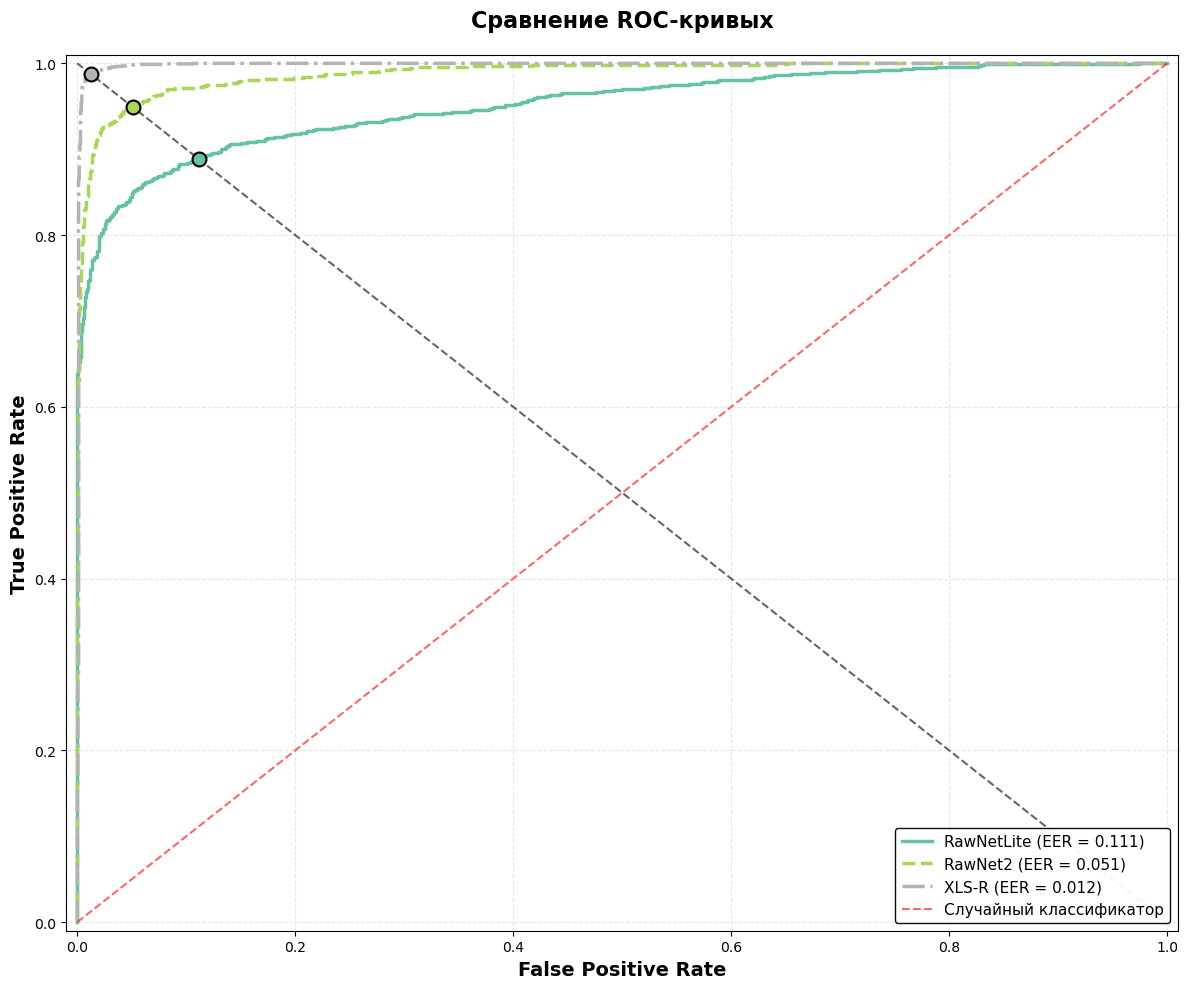

{'RawNetLite': {'EER': 0.11130952380952391, 'Threshold': array(0.49548268)},
 'RawNet2': {'EER': 0.0511904761908197, 'Threshold': array(0.35804539)},
 'XLS-R': {'EER': 0.012499999999999959, 'Threshold': array(0.98836029)}}

In [26]:
visualize_eer(test_df['label'], probas_dict, title="Сравнение ROC-кривых")

In [27]:
results = {
    "RawNetLite": {
        "EER": rawnetlite_test_eer,
        "ROC-AUC": roc_auc_score(test_df['label'], rawnetlite_test_probas),
        "Threshold": rawnetlite_train_thr,
        "Accuracy": rawnetlite_test_accuracy
    },
    "RawNet2": {
        "EER": rawnet2_test_eer,
        "ROC-AUC": roc_auc_score(test_df['label'], rawnet2_test_probas),
        "Threshold": rawnet2_train_thr,
        "Accuracy": rawnet2_test_accuracy
    },
    "XLS-R": {
        "EER": xlsr_test_eer,
        "ROC-AUC": roc_auc_score(test_df['label'], xlsr_test_probas),
        "Threshold": xlsr_train_thr,
        "Accuracy": xlsr_test_accuracy
    }
}

In [28]:
print("="*70)
print(f"{'Model':<25} {'AUC':<10} {'EER':<10} {'Threshold':<15} {'Accuracy':<10}")
print("="*70)
for model in results:
    print(f"{model:<25} {results[model]['ROC-AUC']:<10.4f} {results[model]['EER']:<10.4f} {results[model]['Threshold']:<10.4f} {results[model]['Accuracy']:<10.4f}")
print("="*70)

Model                     AUC        EER        Threshold       Accuracy  
RawNetLite                0.9517     0.1113     0.4919     0.8881    
RawNet2                   0.9884     0.0512     0.3100     0.9470    
XLS-R                     0.9984     0.0125     0.9835     0.9881    


In [29]:
def visualize_detection_rates(test_df, model_names, figsize=(12, 6)):
    tts_df = test_df[test_df['tts_model'].notna()]
    tts_models = sorted(tts_df['tts_model'].unique())
    
    detection_rates = {}
    
    for model_name in model_names:
        detection_rates[model_name] = []
        
        for tts_model in tts_models:
            df_subset = tts_df[tts_df['tts_model'] == tts_model]
            rate = df_subset[model_name].sum() / len(df_subset) * 100 if len(df_subset) > 0 else 0
            detection_rates[model_name].append(rate)
    
    n_models = len(detection_rates)
    n_tts = len(tts_models)
    
    # Позиции для столбцов
    x = np.arange(n_tts)
    width = 0.8 / n_models  # Ширина столбца
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Цвета для моделей
    colors = plt.cm.Set2(np.linspace(0, 1, n_models))
    
    # Рисуем столбцы для каждой модели
    for i, (model_name, rates) in enumerate(detection_rates.items()):
        offset = (i - n_models/2 + 0.5) * width
        bars = ax.bar(x + offset, rates, width, 
                      label=model_name, color=colors[i], edgecolor='black')
        
        # Добавляем значения над столбцами
        for bar, rate in zip(bars, rates):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                   f'{rate:.1f}%', ha='center', va='bottom', fontsize=9)
    
    # Настройки графика
    ax.set_xlabel('TTS Модели', fontsize=12, fontweight='bold')
    ax.set_ylabel('Доля обнаруженных дипфейков (%)', fontsize=12, fontweight='bold')
    ax.set_title('Эффективность детектирования по TTS-моделям', 
                fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(tts_models, rotation=0, fontsize=11)
    ax.set_ylim(0, 105)
    ax.legend(title='Модели детектирования', fontsize=10, title_fontsize=11)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Добавляем горизонтальную линию на 100%
    ax.axhline(y=100, color='red', linestyle='--', alpha=0.5, linewidth=1)
    
    plt.tight_layout()
    plt.show()
    
    return detection_rates, tts_models

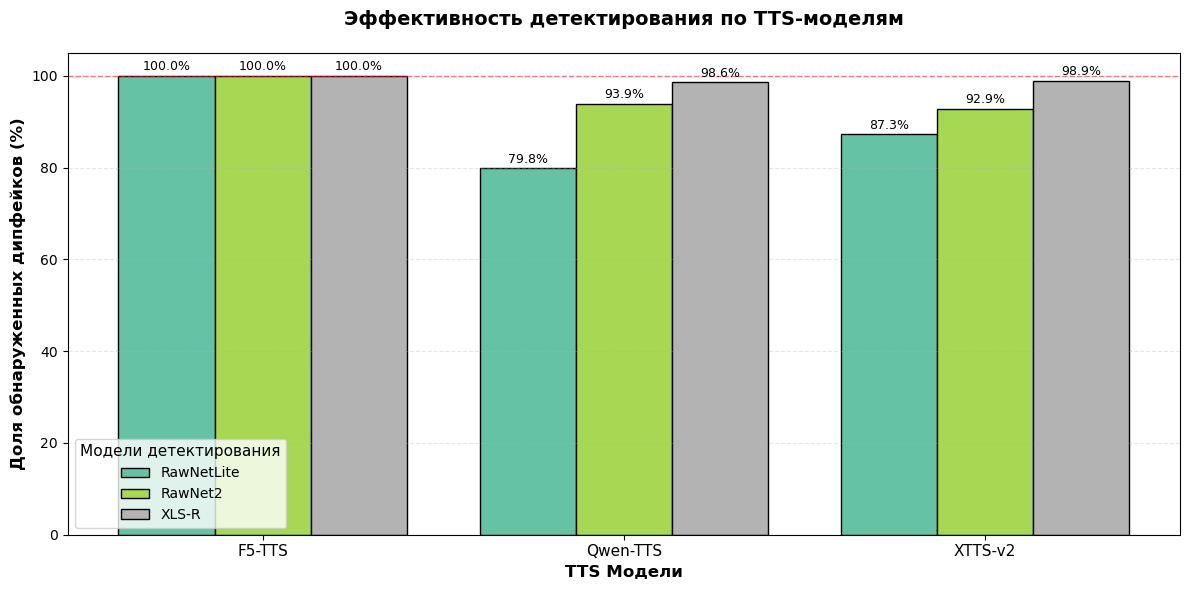

In [30]:
labels_dict = {
    "RawNetLite": rawnetlite_test_predictions,
    "RawNet2": rawnet2_test_predictions,
    "XLS-R": xlsr_test_predictions
}

for model in labels_dict:
    test_df[model] = labels_dict[model]

model_names = list(labels_dict.keys())
visualize_detection_rates(test_df, model_names);